In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"]=(12,6)

import warnings
warnings.filterwarnings("ignore")

In [9]:
df = pd.read_csv(
    "../data/raw/final_dataset.csv"
)

In [35]:
df.shape

(54340, 28)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54340 entries, 0 to 54339
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   State            54340 non-null  str    
 1   Commodity_Group  54340 non-null  str    
 2   Commodity        54340 non-null  str    
 3   Date             54340 non-null  str    
 4   Arrival          54340 non-null  float64
 5   Arrival_Unit     54340 non-null  str    
 6   Modal_Price      54340 non-null  float64
 7   Price_Unit       54340 non-null  str    
 8   District         54340 non-null  str    
 9   Max_Temp         54340 non-null  float64
 10  Min_Temp         54340 non-null  float64
 11  Rainfall_mm      54340 non-null  float64
 12  Rain_mm          54340 non-null  float64
 13  WindSpeed        54340 non-null  float64
 14  Festival         54340 non-null  str    
 15  Holiday          54340 non-null  float64
 16  Month            54340 non-null  int64  
 17  Year             54340 

df.isnull().sum()

In [37]:
df.describe()

,Arrival,Modal_Price,Max_Temp,Min_Temp,Rainfall_mm,Rain_mm,WindSpeed,Holiday,Month,Year,Day,DayOfWeek,Quarter,Lag_1,Lag_2,Lag_3,Rolling_7,Rolling_30,Price_Change
count,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000,54340.000000
mean,5378.557335,2552.735193,31.429525,20.869026,3.232563,3.232563,16.722968,0.037357,6.525212,2024.001288,15.756717,2.996688,2.508281,2552.680169,2552.625146,2552.570122,2552.570122,2551.884472,0.055024
std,9483.842305,1352.557799,4.150069,3.469216,7.925231,7.925231,5.492728,0.189638,3.448027,0.817667,8.816977,2.002315,1.117684,1352.554929,1352.552057,1352.549183,1343.177200,1321.698646,148.681748
min,0.100000,349.390000,22.100000,9.500000,0.000000,0.000000,4.600000,0.000000,1.000000,2023.000000,1.000000,0.000000,1.000000,349.390000,349.390000,349.390000,349.390000,356.183333,-9380.280000
25%,439.940000,1346.360000,28.400000,18.600000,0.000000,0.000000,12.600000,0.000000,4.000000,2023.000000,8.000000,1.000000,2.000000,1346.360000,1346.360000,1346.360000,1350.800000,1353.047833,0.000000
50%,1551.000000,2495.065000,30.400000,21.500000,0.000000,0.000000,15.800000,0.000000,7.000000,2024.000000,16.000000,3.000000,3.000000,2494.640000,2494.640000,2494.640000,2504.665000,2522.319667,0.000000
75%,3359.200000,3640.270000,34.000000,23.000000,2.400000,2.400000,20.200000,0.000000,10.000000,2025.000000,23.000000,5.000000,4.000000,3640.270000,3640.270000,3640.270000,3623.358214,3582.556667,0.000000
max,80038.120000,10886.270000,45.500000,32.500000,241.900000,241.900000,49.900000,1.000000,12.000000,2025.000000,31.000000,6.000000,4.000000,10886.270000,10886.270000,10886.270000,10886.270000,9181.853333,9504.150000


Analysis 1
Dataset Overview

In [38]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])
print("Commodities :",df["Commodity"].nunique())
print("Districts :",df["District"].nunique())
print("Years :",df["Year"].nunique())

Rows : 54340
Columns : 28
Commodities : 5
Districts : 10
Years : 3


Analysis 2
Commodity Distribution

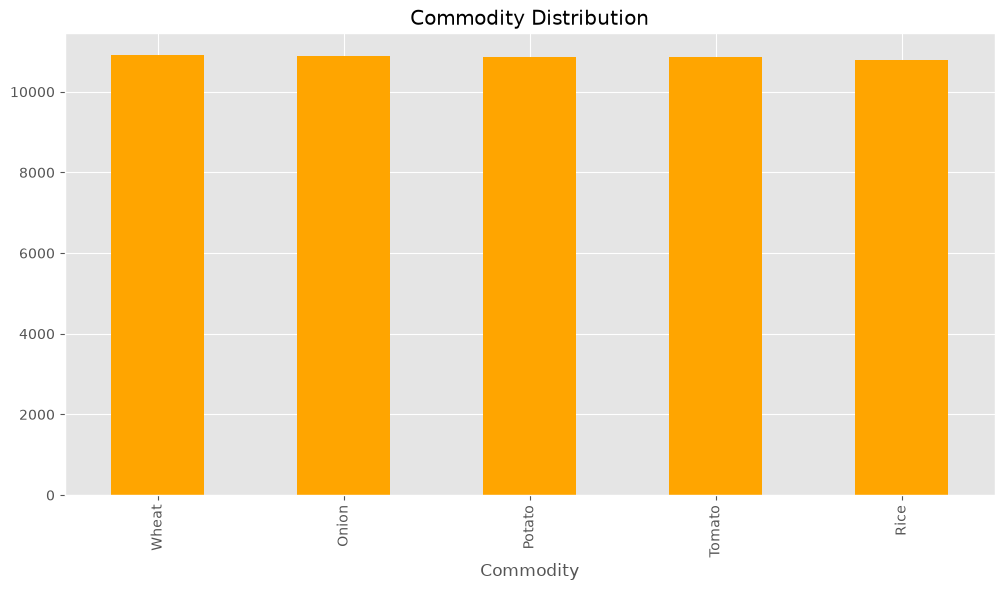

In [39]:
df["Commodity"].value_counts().plot(
    kind="bar",
    color="orange"
)

plt.title("Commodity Distribution")
plt.show()

Analysis 3
District Distribution

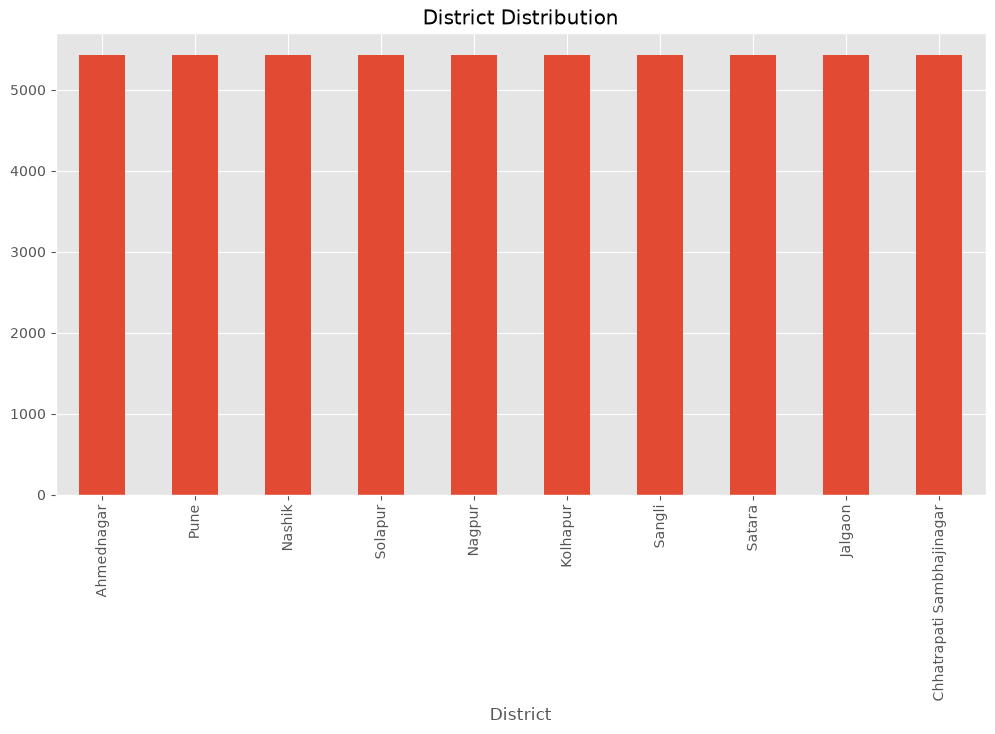

In [40]:
df["District"].value_counts().plot(
    kind="bar"
)

plt.title("District Distribution")
plt.show()

Analysis 4
Monthly Average Price

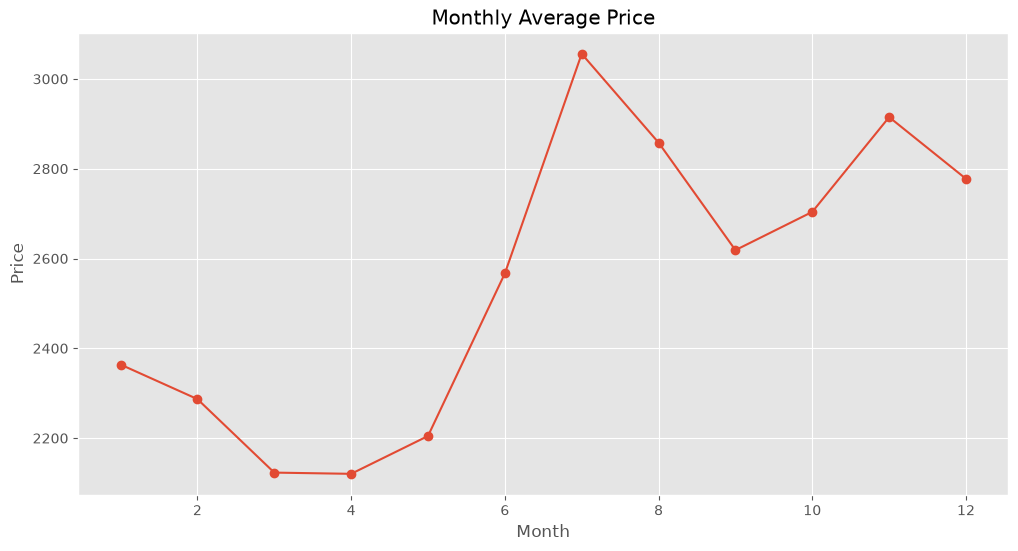

In [41]:
monthly=df.groupby("Month")["Modal_Price"].mean()

monthly.plot(marker="o")

plt.title("Monthly Average Price")
plt.ylabel("Price")
plt.show()

Analysis 5
Highest Price Month

In [42]:
monthly.sort_values(ascending=False)

Month
7     3055.847823
11    2914.901742
8     2858.082172
12    2777.447000
10    2703.854030
9     2618.650844
6     2566.747222
1     2363.832688
2     2286.876492
5     2204.688326
3     2123.178753
4     2120.450349
Name: Modal_Price, dtype: float64

Analysis 6
Lowest Price Month

In [43]:
monthly.sort_values()

Month
4     2120.450349
3     2123.178753
5     2204.688326
2     2286.876492
1     2363.832688
6     2566.747222
9     2618.650844
10    2703.854030
12    2777.447000
8     2858.082172
11    2914.901742
7     3055.847823
Name: Modal_Price, dtype: float64

Analysis 7
Commodity-wise Average Price

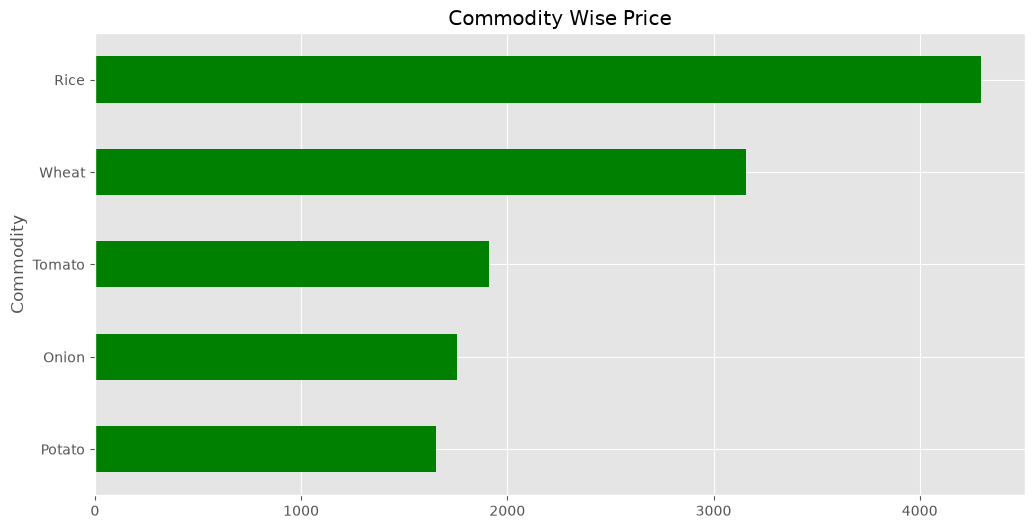

In [44]:
commodity=df.groupby("Commodity")["Modal_Price"].mean()

commodity.sort_values().plot(
    kind="barh",
    color="green"
)

plt.title("Commodity Wise Price")
plt.show()

Analysis 8
District-wise Average Price

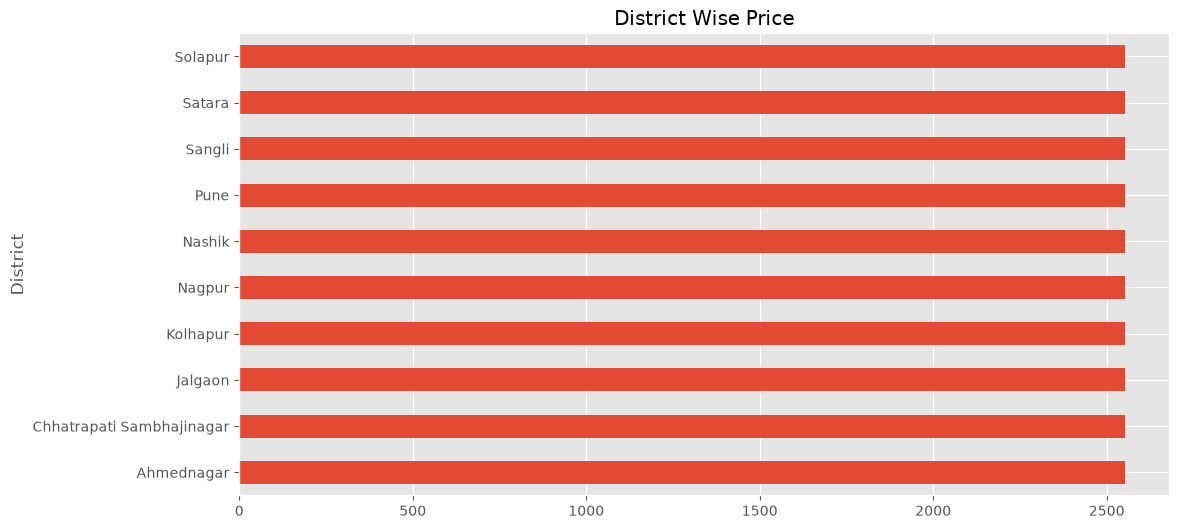

In [45]:
district=df.groupby("District")["Modal_Price"].mean()

district.sort_values().plot(
    kind="barh"
)

plt.title("District Wise Price")
plt.show()

Analysis 9
Arrival vs Price

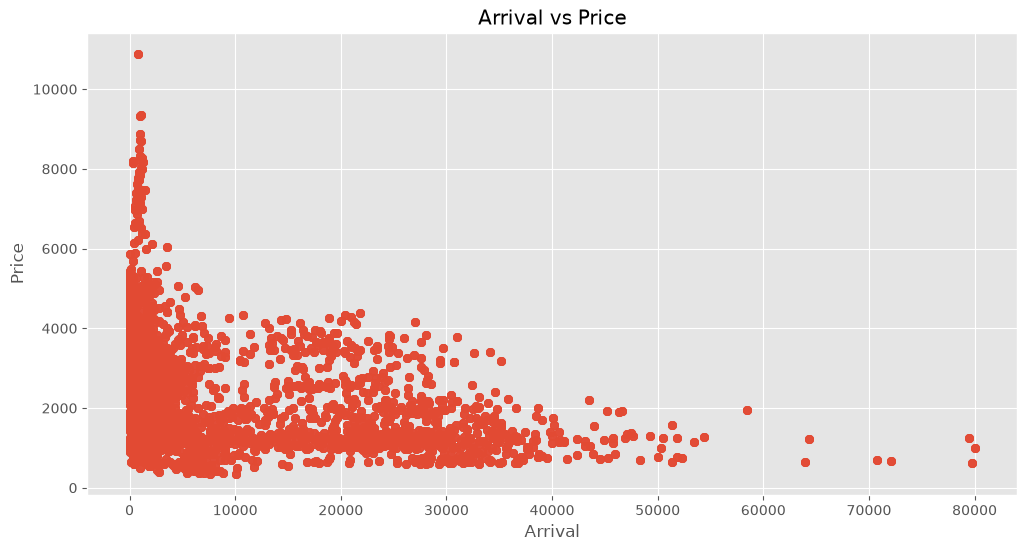

In [46]:
plt.scatter(
    df["Arrival"],
    df["Modal_Price"],
    alpha=0.3
)

plt.xlabel("Arrival")

plt.ylabel("Price")

plt.title("Arrival vs Price")

plt.show()

Analysis 10
Rainfall vs Price

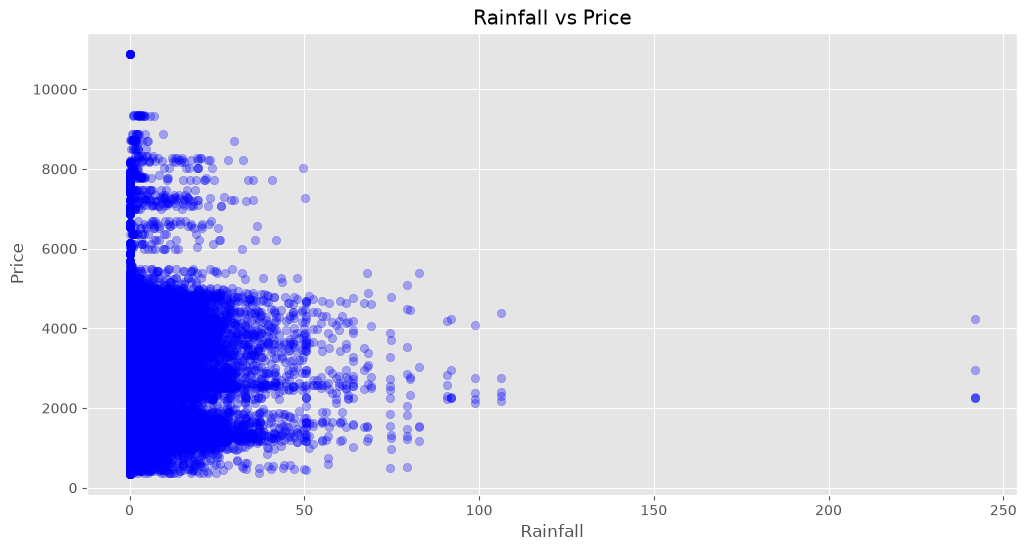

In [47]:
plt.scatter(
    df["Rainfall_mm"],
    df["Modal_Price"],
    alpha=0.3,
    color="blue"
)

plt.xlabel("Rainfall")

plt.ylabel("Price")

plt.title("Rainfall vs Price")

plt.show()

Analysis 11
Temperature vs Price

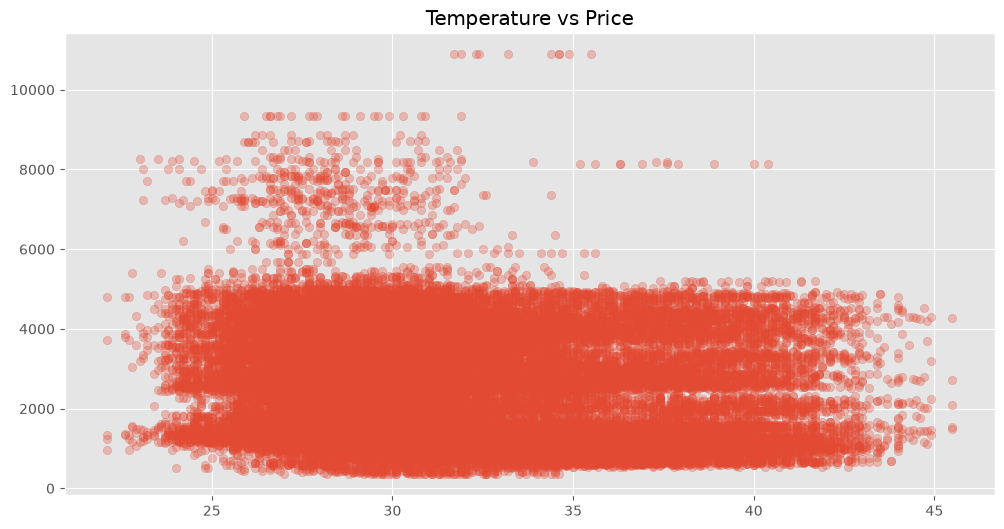

In [48]:
plt.scatter(
    df["Max_Temp"],
    df["Modal_Price"],
    alpha=0.3
)

plt.title("Temperature vs Price")

plt.show()

Analysis 12
Festival Impact

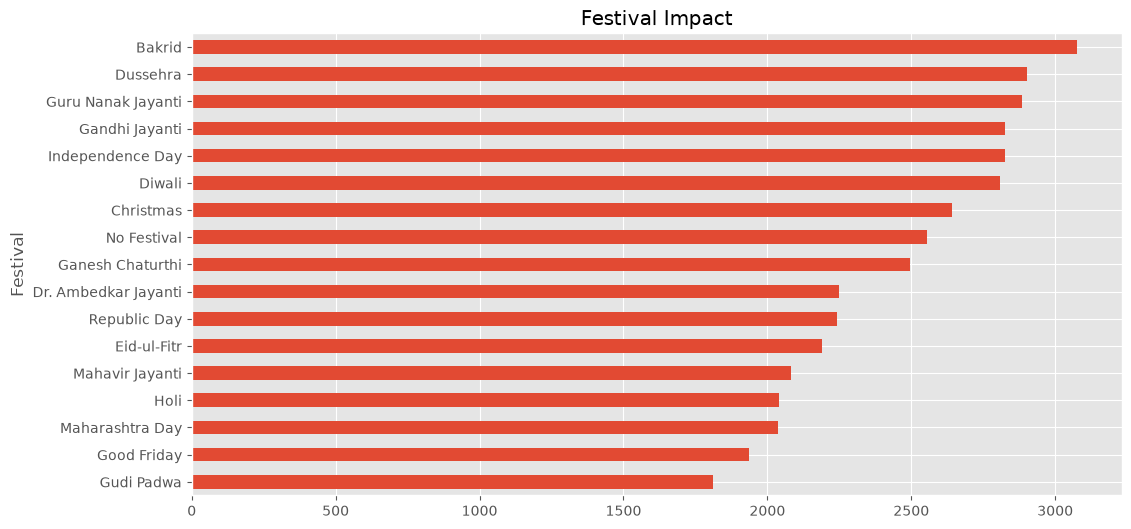

In [49]:
festival=df.groupby("Festival")["Modal_Price"].mean()

festival.sort_values().plot(
    kind="barh"
)

plt.title("Festival Impact")

plt.show()

Analysis 13
Weekend vs Weekday

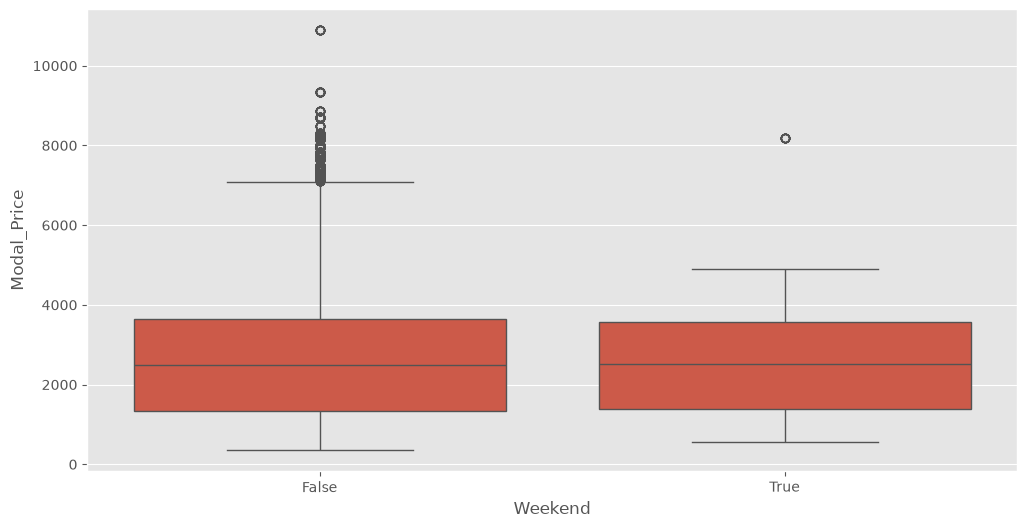

In [50]:
sns.boxplot(
    x="Weekend",
    y="Modal_Price",
    data=df
)

plt.show()

Analysis 14
Correlation Heatmap

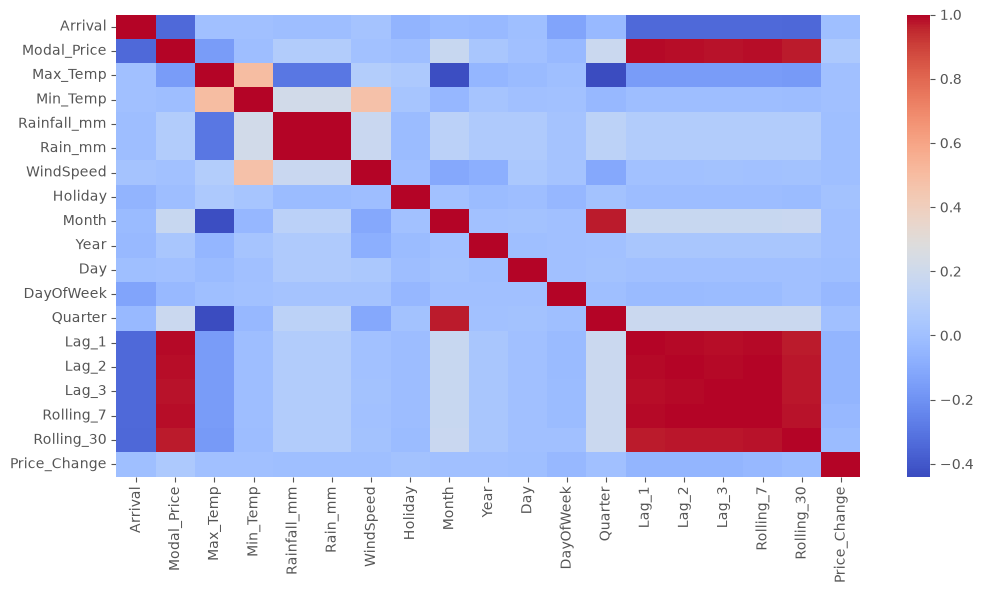

In [51]:
numeric=df.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm"
)

plt.show()

Analysis 15
Price Distribution

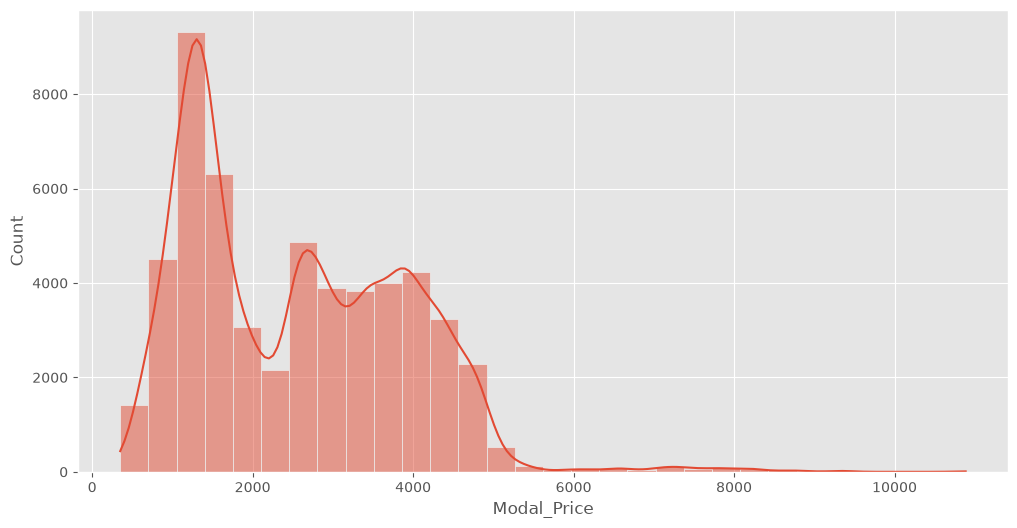

In [52]:
sns.histplot(
    df["Modal_Price"],
    bins=30,
    kde=True
)

plt.show()

Analysis 16
Price Boxplot

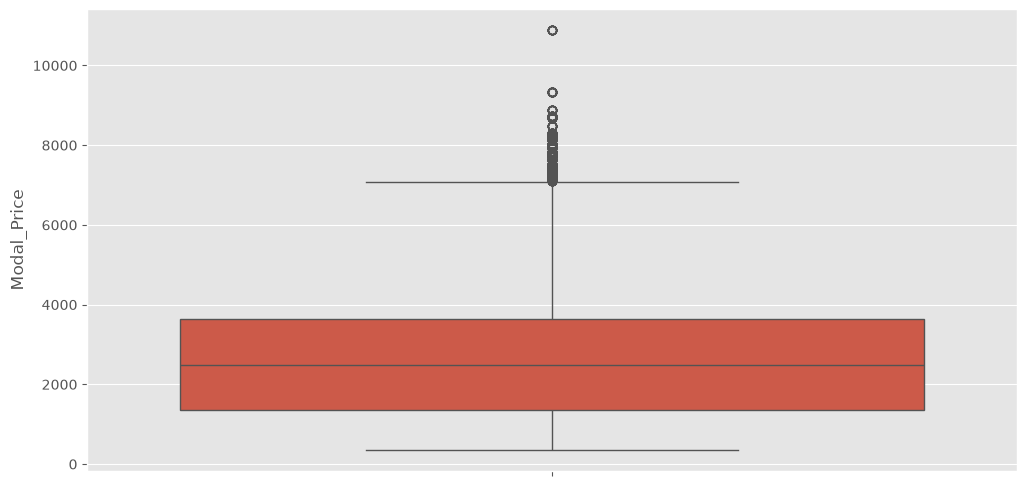

In [53]:
sns.boxplot(
    y=df["Modal_Price"]
)

plt.show()

Analysis 17
Yearly Trend

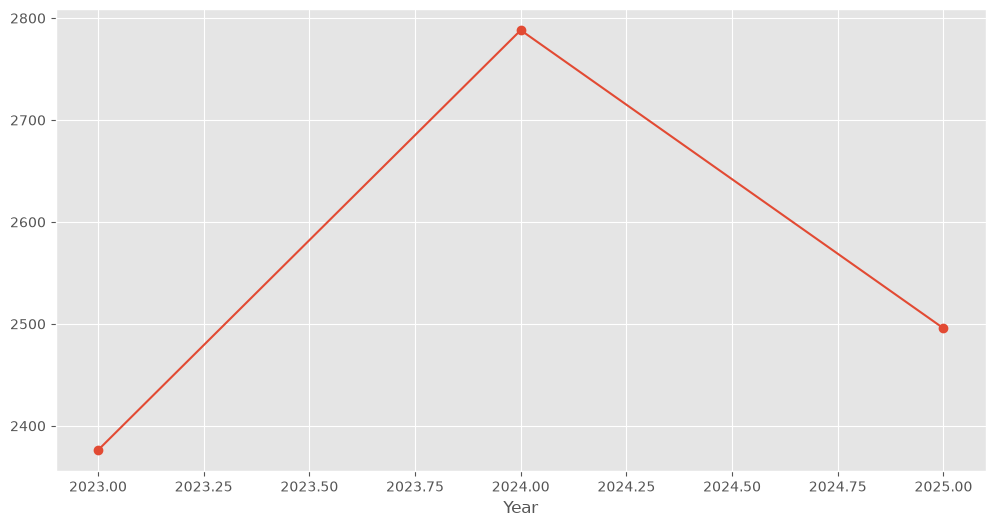

In [54]:
year=df.groupby("Year")["Modal_Price"].mean()

year.plot(marker="o")

plt.show()

Analysis 18
Commodity vs Arrival

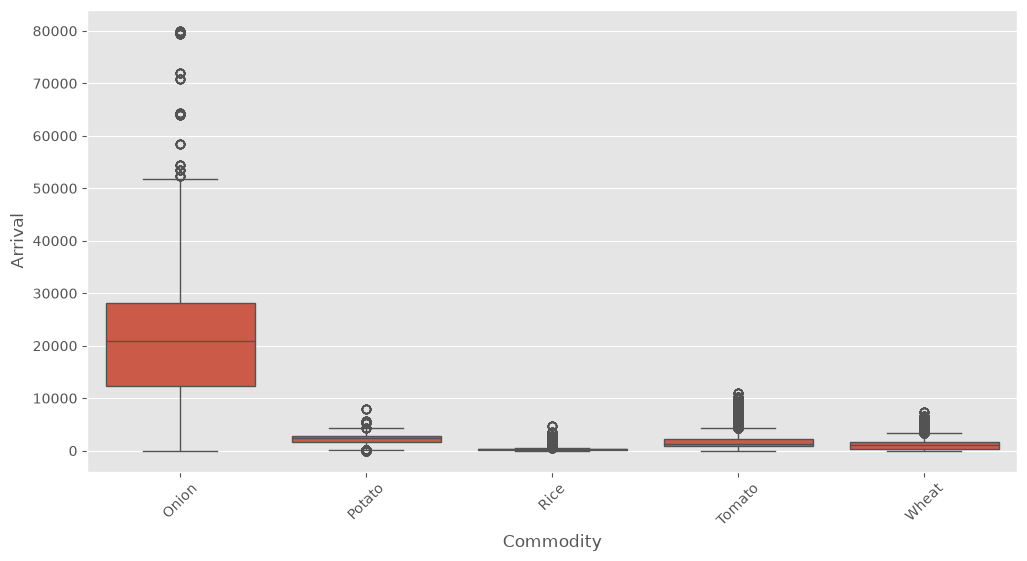

In [55]:
sns.boxplot(
    x="Commodity",
    y="Arrival",
    data=df
)

plt.xticks(rotation=45)

plt.show()

Analysis 19
Price Change Distribution

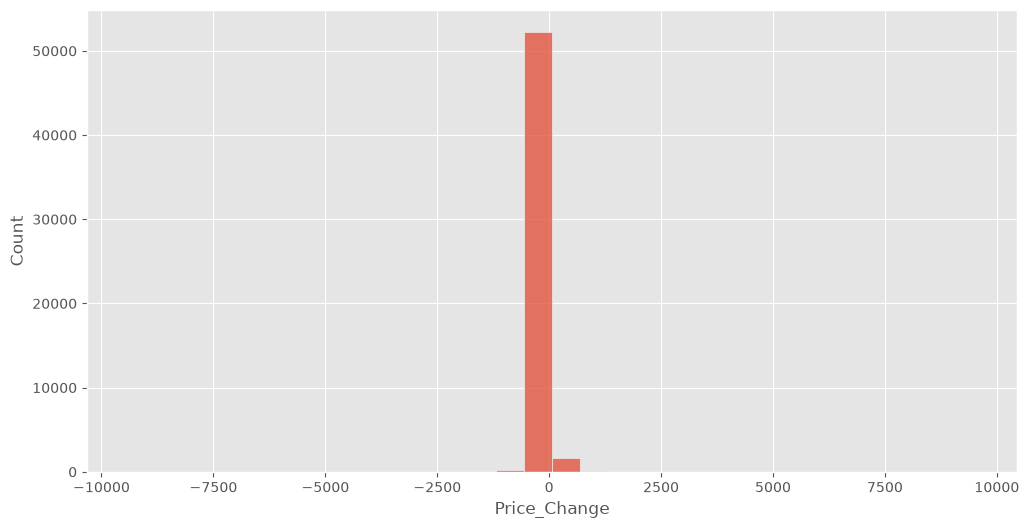

In [56]:
sns.histplot(
    df["Price_Change"],
    bins=30
)

plt.show()

Analysis 20
Rolling Average

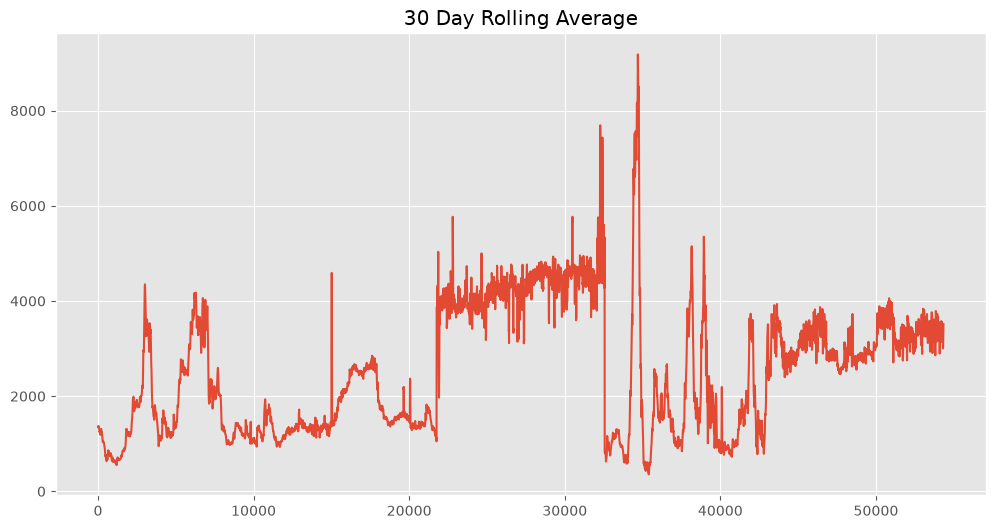

In [57]:
df["Rolling_30"].plot()

plt.title("30 Day Rolling Average")

plt.show()

Analysis 21
Feature Importance (Random Forest)

Load your trained model and visualize the feature importances:

In [33]:
import joblib

rf = joblib.load("../models/price_prediction_model.pkl")

importance = pd.DataFrame({
    "Feature": rf.feature_names_in_,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
17,Lag_1,0.984292
22,Price_Change,0.009821
20,Rolling_7,0.005114
3,Arrival,0.000143
21,Rolling_30,0.000079
15,DayOfWeek,0.000057
12,Year,0.000057
11,Month,0.000055
5,Max_Temp,0.000051
6,Min_Temp,0.000045


Analysis 22
Top 10 Important Features

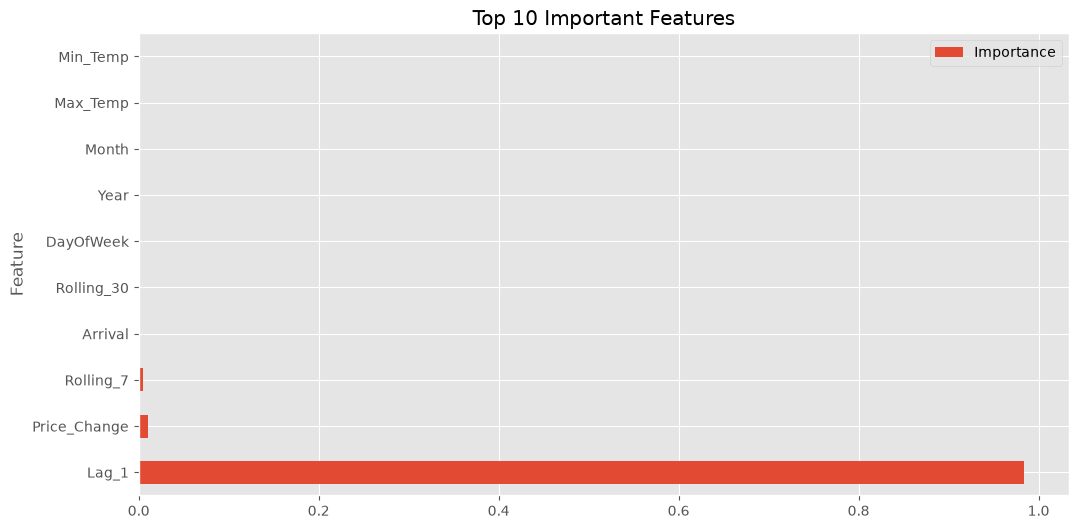

In [34]:
importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title("Top 10 Important Features")

plt.show()